# 6. Outliers

Continues from [0_load_and_orient.ipynb](0_load_and_orient.ipynb) — reloads
the same setup so this notebook runs standalone. Train-only, same
reasoning as [4_bivariate.ipynb](4_bivariate.ipynb) and
[5_multicollinearity.ipynb](5_multicollinearity.ipynb): there's no
`SalePrice` in `test.csv` to check outliers against, and injecting
knowledge from a supervised check into `df_test` would leak.

Three angles, each catching a different kind of anomaly:

1. **Univariate** — a single column's value is extreme on its own (IQR rule).
2. **Bivariate / regression residual** — a row doesn't fit the
   price-vs-features relationship, even if no single value is extreme.
3. **Multivariate** — an unusual *combination* of feature values, regardless
   of price.

**Scope:** flag rows for a modeling-time decision (drop, downweight,
investigate) — nothing is removed from `df_train` here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression


In [2]:
df_train = pd.read_csv("../../data/train.csv")


In [3]:
IDENTIFIER = ["Id"]
TARGET = ["SalePrice"]

NUMERIC_COLS = sorted([
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath",
    "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF",
    "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
    "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold",
])

ORDINAL_COLS = sorted([
    "OverallQual", "OverallCond", "LotShape", "LandSlope",
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual",
    "Functional", "FireplaceQu", "GarageFinish", "GarageQual",
    "GarageCond", "PavedDrive", "PoolQC", "Utilities",
])

NOMINAL_COLS = sorted([
    "MSSubClass", "MSZoning", "Street", "Alley", "LandContour", "LotConfig",
    "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle",
    "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType",
    "Foundation", "Heating", "CentralAir", "Electrical", "GarageType",
    "MiscFeature", "SaleType", "SaleCondition", "Fence",
])

all_cols = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS
expected = set(df_train.columns) - set(IDENTIFIER) - set(TARGET)
assert set(all_cols) == expected, set(all_cols) ^ expected
assert len(all_cols) == len(expected)
len(NUMERIC_COLS), len(ORDINAL_COLS), len(NOMINAL_COLS)


(33, 21, 25)

In [4]:
ORDER = {
    "OverallQual": list(range(1, 11)),
    "OverallCond": list(range(1, 11)),
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "FireplaceQu": ["Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["Unf", "RFn", "Fin"],
    "GarageQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "PavedDrive": ["N", "P", "Y"],
    "PoolQC": ["Fa", "TA", "Gd", "Ex"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
}
assert set(ORDER.keys()) == set(ORDINAL_COLS)

ordinal_encoded = pd.DataFrame({
    col: df_train[col].map({level: i for i, level in enumerate(ORDER[col])})
    for col in ORDINAL_COLS
})

log_sale_price = pd.Series(np.log1p(df_train["SalePrice"]), name="log_sale_price")


## 1. Univariate outliers

IQR rule (1.5x) on the 8 genuinely continuous size columns identified in
[4_bivariate.ipynb](4_bivariate.ipynb) (`SIZE_COLS` — the columns left
after splitting out zero-inflated and low-cardinality counts). Applying
IQR to a zero-inflated column like `PoolArea` would just flag "has one" as
an outlier, which isn't the question here.

In [5]:
SIZE_COLS = sorted([
    "1stFlrSF", "BsmtFinSF1", "BsmtUnfSF", "GarageArea",
    "GrLivArea", "LotArea", "LotFrontage", "TotalBsmtSF",
])

iqr_summary = []
for col in SIZE_COLS:
    s = df_train[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    iqr_summary.append({"col": col, "lo": lo, "hi": hi, "n_outliers": n_out, "max": s.max()})
iqr_summary = pd.DataFrame(iqr_summary).sort_values("n_outliers", ascending=False)
iqr_summary


,col,lo,hi,n_outliers,max
6,LotFrontage,27.500,111.500,88,313.0
5,LotArea,1481.500,17673.500,69,215245.0
7,TotalBsmtSF,42.000,2052.000,61,6110.0
4,GrLivArea,158.625,2747.625,31,5642.0
2,BsmtUnfSF,-654.500,1685.500,29,2336.0
3,GarageArea,-27.750,938.250,21,1418.0
0,1stFlrSF,118.125,2155.125,20,4692.0
1,BsmtFinSF1,-1068.375,1780.625,7,5644.0


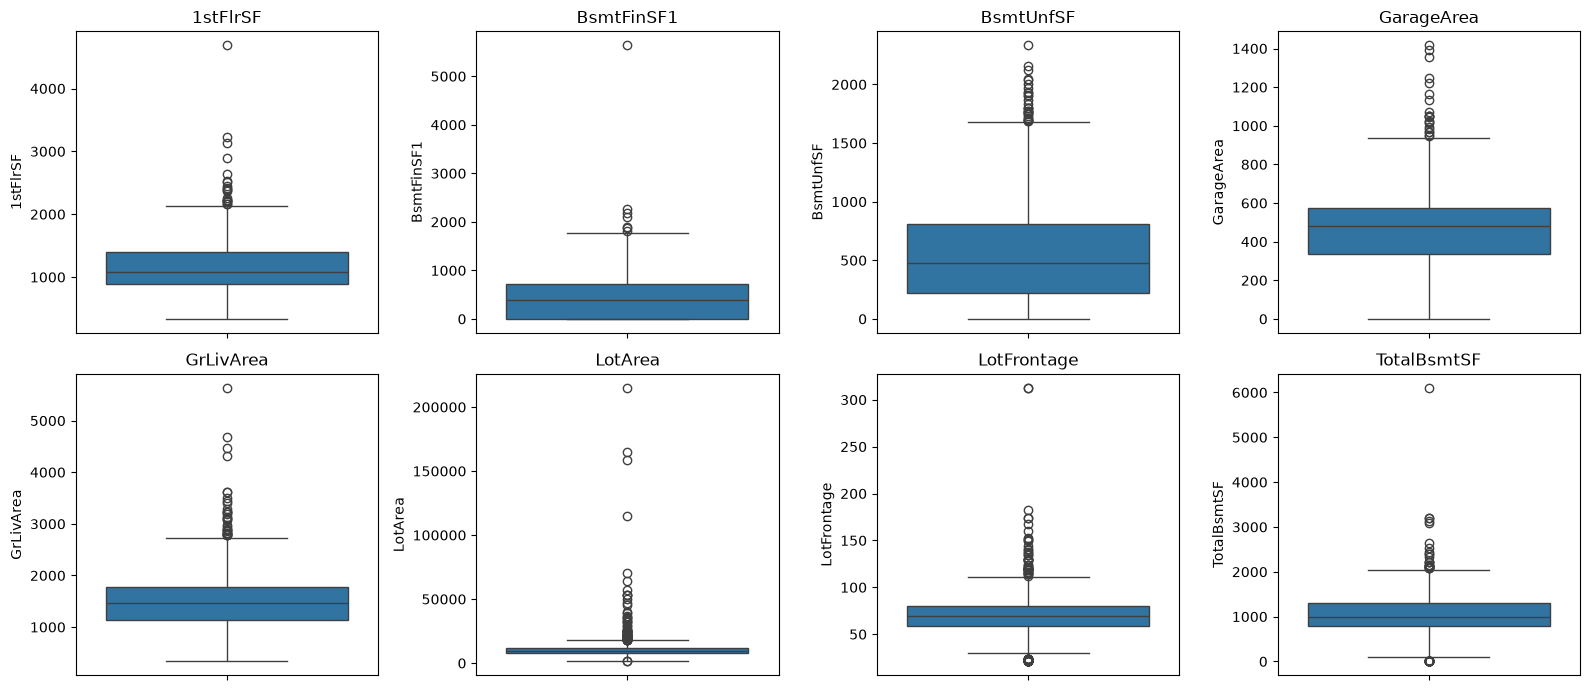

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, SIZE_COLS):
    sns.boxplot(y=df_train[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Reading this:** every size column has IQR outliers (7-88 rows) — normal
for right-skewed size data, and already flagged as transform candidates in
[3_univariate.ipynb](3_univariate.ipynb)/[4_bivariate.ipynb](4_bivariate.ipynb).
IQR-on-a-skewed-distribution flags the same upper tail a log transform
would compress, not necessarily bad data. `LotFrontage` (88) and `LotArea`
(69) have the most — consistent with them being the most heavily skewed
size columns already on record. This section is a volume check, not a
verdict; the sharper question is whether an extreme value also breaks the
price relationship, which is what the next two sections check.

## 2. Bivariate / regression residual outliers

### The known `GrLivArea` pattern

Ames housing writeups commonly flag a handful of very large homes that sold
far below what their size and quality would predict — worth checking
directly rather than assuming it applies here.

In [7]:
big_area = df_train[df_train["GrLivArea"] > 4000][
    ["Id", "GrLivArea", "OverallQual", "SalePrice", "SaleCondition"]
].sort_values("GrLivArea")
big_area


,Id,GrLivArea,OverallQual,SalePrice,SaleCondition
691,692,4316,10,755000,Normal
1182,1183,4476,10,745000,Abnorml
523,524,4676,10,184750,Partial
1298,1299,5642,10,160000,Partial


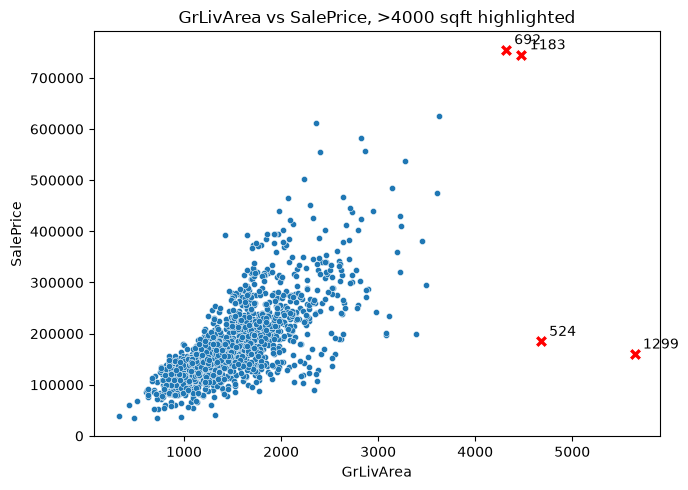

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_train, x="GrLivArea", y="SalePrice", s=20, ax=ax)
sns.scatterplot(data=big_area, x="GrLivArea", y="SalePrice", s=80, color="red", marker="X", ax=ax)
for _, row in big_area.iterrows():
    ax.annotate(int(row["Id"]), (row["GrLivArea"], row["SalePrice"]), textcoords="offset points", xytext=(6, 4))
ax.set_title("GrLivArea vs SalePrice, >4000 sqft highlighted")
plt.tight_layout()
plt.show()


4 rows top 4000 sqft, all `OverallQual`=10 (the maximum). Two
(`Id` 692, 1183) sold for $745-755k — huge, top-quality, and expensive:
consistent with the price relationship, not outliers in the sense that
matters. The other two (`Id` 524, 1299) sold for $160-185k — enormous,
top-quality homes at a price more typical of an average-size house. Both
are `SaleCondition` `Partial` (new construction, sold before completion),
a plausible real-world reason the sale price wouldn't reflect the
finished size. Whether that's grounds to drop them is a modeling
decision; here it's a specific, named flag rather than "there might be
outliers."

### Regression residuals

A simple two-feature fit (`OverallQual` + `GrLivArea` — the two strongest
single predictors of `log_sale_price` per
[4_bivariate.ipynb](4_bivariate.ipynb)'s correlation ranking) generalizes
the `GrLivArea`-only check: which rows don't fit the price relationship at
all, not just on this one column.

In [9]:
X = np.column_stack([ordinal_encoded["OverallQual"], df_train["GrLivArea"]])
lr = LinearRegression().fit(X, log_sale_price)
resid = log_sale_price - lr.predict(X)
resid_z = (resid - resid.mean()) / resid.std()

print(f"R2: {lr.score(X, log_sale_price):.3f}")
print(f"rows with |standardized residual| > 3: {(resid_z.abs() > 3).sum()}")

residual_outliers = (
    df_train.loc[resid_z.abs() > 3, ["Id", "GrLivArea", "OverallQual", "SalePrice"]]
    .assign(resid_z=resid_z[resid_z.abs() > 3].round(2))
    .sort_values("resid_z")
)
residual_outliers


R2: 0.740
rows with |standardized residual| > 3: 17


,Id,GrLivArea,OverallQual,SalePrice,resid_z
1298,1299,5642,10,160000,-8.77
523,524,4676,10,184750,-6.86
30,31,1317,4,40000,-4.92
495,496,720,4,34900,-4.84
1349,1350,2358,8,122000,-4.25
632,633,1411,7,82500,-4.11
968,969,968,3,37900,-3.87
812,813,1044,5,55993,-3.80
410,411,1276,5,60000,-3.75
431,432,1198,6,79900,-3.13


17 rows clear |z|>3. `Id` 1299 (-8.8) and 524 (-6.9) are far beyond
everything else — the same two `GrLivArea`-driven Partial-sale homes from
above, now confirmed as extreme on the full price relationship, not just
big-and-cheap in isolation. The rest of the list runs both directions:
several small, low-quality homes selling for less than the fit predicts
(`Id` 496, 969 — modest houses, `OverallQual` 3-4), and at least one
(`Id` 458) selling notably *above* the fit (+3.77) — a `resid_z` outlier
isn't automatically an "overpriced" or "underpriced" story, both
directions get flagged the same way.

## 3. Multivariate outliers

`IsolationForest` looks for unusual *combinations* of feature values across
all numeric + ordinal columns at once, independent of price — a row can be
flagged here even if it fits the price relationship perfectly, if its
feature values are jointly unusual (e.g. a huge, expensive house is a
normal combination; a huge, cheap, one-bathroom house isn't).

Same complete-case handling as
[5_multicollinearity.ipynb](5_multicollinearity.ipynb): drop the two
columns too sparse to use (`PoolQC`, `FireplaceQu`), `.dropna()` the rest
— row-exclusion for a throwaway diagnostic, not a fill.

In [10]:
combined = pd.concat([df_train[NUMERIC_COLS], ordinal_encoded], axis=1)
iso_cols = [c for c in combined.columns if c not in ("PoolQC", "FireplaceQu")]
complete_mask = combined[iso_cols].notna().all(axis=1)
print(f"complete-case rows: {complete_mask.sum()} / {len(combined)}")

iso = IsolationForest(random_state=0, contamination=0.02)
iso_pred = iso.fit_predict(combined.loc[complete_mask, iso_cols])

iso_outlier_ids = set(df_train.loc[complete_mask, "Id"][iso_pred == -1])
print(f"flagged (contamination=2%): {len(iso_outlier_ids)}")


complete-case rows: 1095 / 1460
flagged (contamination=2%): 22


In [11]:
print("overlap with GrLivArea>4000:", sorted(iso_outlier_ids & set(big_area["Id"])))
print("overlap with |resid_z|>3:     ", sorted(iso_outlier_ids & set(residual_outliers["Id"])))


overlap with GrLivArea>4000: [524, 692, 1183, 1299]
overlap with |resid_z|>3:      [524, 1299]


All 4 `GrLivArea`>4000 rows are flagged by `IsolationForest` — including
692 and 1183, which the residual check *didn't* flag because they fit the
price relationship. This is the expected difference between the two
methods: residuals catch "wrong price for these features," isolation
forest catches "unusual features regardless of price." Only 2 of the 17
residual outliers overlap (1299, 524, the two already singled out three
times over) — most of the 22 isolation-forest flags and most of the 17
residual outliers are catching different rows for different reasons, which
is the point of running more than one method rather than picking one.

## Summary

| Method | What it catches | Result |
|---|---|---|
| Univariate IQR | A single column's value is extreme | 7-88 rows per `SIZE_COLS` column; mostly the upper tail a log transform already targets |
| `GrLivArea` > 4000 | The specific, well-known Ames large-home pattern | 4 rows, all `OverallQual`=10; 2 (692, 1183) are big *and* expensive — fit the trend; 2 (524, 1299) are big and cheap, both `SaleCondition`=`Partial` |
| Regression residual (`OverallQual` + `GrLivArea`) | Doesn't fit the price relationship at all | 17 rows at \|z\|>3; 524 and 1299 dominate (-6.9, -8.8), far beyond the rest |
| `IsolationForest` (all numeric+ordinal) | Unusual combination of features, independent of price | 22 rows flagged; includes all 4 `GrLivArea`>4000 rows (692/1183 only show up here, not in residuals) |

**Candidates carried forward to preprocessing / modeling:**

- **`Id` 524 and 1299**: flagged by every method that touches price
  (`GrLivArea`>4000, residual, isolation forest) — the strongest, most
  triangulated outlier candidates in the dataset. Both `SaleCondition`
  `Partial`, both `OverallQual` 10. The clearest case for exclusion (or a
  `SaleCondition`-aware model) at training time, consistent with the
  pattern commonly reported for this dataset.
- **`Id` 692 and 1183**: large and expensive, fit the price trend, but
  flagged by `IsolationForest` as an unusual feature combination — lower
  priority than 524/1299, worth a look rather than automatic exclusion.
- **The other 15 residual outliers**: no single dominant pattern — a mix
  of small/low-quality homes underselling and one (`Id` 458) overselling
  relative to the two-feature fit. Revisit once the actual modeling
  feature set is larger than `OverallQual` + `GrLivArea`; a fuller model
  may explain several of these away.
- **`SaleCondition`**: both of the strongest outliers share
  `Partial` — worth checking whether `SaleCondition` deserves a bigger
  role in the model (e.g. as an interaction or a subset-specific
  adjustment) rather than treating these purely as rows to drop.
- **Boundary held:** every row above is flagged, not removed — `df_train`
  is unchanged; the drop/keep decision belongs to whoever trains the
  model, informed by the specific reasons collected here rather than a
  blanket outlier-removal rule.